In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif # Import f_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

**STEP-2: DATA LOADING AND INITIAL EXPLORATION**.

In [ ]:
# Load the dataset
df = pd.read_csv('/content/data.csv')

# Initial exploration
print(f"Dataset shape: {df.shape}")

Dataset shape: (48842, 15)


In [ ]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-per-week nativ

In [ ]:
print("\nData types and missing values:")
print(df.info())


Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None


In [ ]:
print("\nSummary statistics:")
print(df.describe(include='all'))


Summary statistics:
                 age workclass        fnlwgt education  educational-num  \
count   48842.000000     48842  4.884200e+04     48842     48842.000000   
unique           NaN         9           NaN        16              NaN   
top              NaN   Private           NaN   HS-grad              NaN   
freq             NaN     33906           NaN     15784              NaN   
mean       38.643585       NaN  1.896641e+05       NaN        10.078089   
std        13.710510       NaN  1.056040e+05       NaN         2.570973   
min        17.000000       NaN  1.228500e+04       NaN         1.000000   
25%        28.000000       NaN  1.175505e+05       NaN         9.000000   
50%        37.000000       NaN  1.781445e+05       NaN        10.000000   
75%        48.000000       NaN  2.376420e+05       NaN        12.000000   
max        90.000000       NaN  1.490400e+06       NaN        16.000000   

            marital-status      occupation relationship   race gender  \
count

In [ ]:
df.tail(7)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48835,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
48836,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


**STEP-3: DATA CLEANING.**

In [ ]:
df.isna()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48838,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48839,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48840,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Check missing values
print("Missing values per column:")
df.isna().sum()

Missing values per column:


,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
print(df.occupation.value_counts())

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
?                    2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64


In [ ]:
print(df.gender.value_counts())

gender
Male      32650
Female    16192
Name: count, dtype: int64


In [ ]:
print(df['marital-status'].value_counts())

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64


In [ ]:
print(df['education'].value_counts())

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


In [ ]:
print(df['workclass'].value_counts())

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


In [ ]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

In [ ]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [ ]:
# Handle missing values
# For categorical columns, use mode imputation
cat_cols = ['workclass', 'occupation', 'native-country']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
# For numerical columns, use median imputation
num_cols = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [ ]:
# Verify no missing values remain
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


**STEP-4: FEATURE ENGINEERING**

In [ ]:
#creating a new column capital-diff(This gives a single number that tells how much capital a person gained or lost overall).
df['capital-diff'] = df['capital-gain'] - df['capital-loss']

In [ ]:
# Creating a new column work-hours(Gives a rough estimate of how much a person has worked over their life).
df['work-hours'] = df['hours-per-week'] * df['age']

In [ ]:
# Created a new feature age-squared(This is done to capture nonlinear patterns).
df['age-squared'] = df['age'] ** 2

In [ ]:
#Simplifying Categorical Features(Grouping several low-education levels under one label: 'School').
df['education'] = df['education'].replace(
    ['11th', '9th', '7th-8th', '5th-6th', '10th', '1st-4th', 'Preschool', '12th'],
    'School'
)

In [ ]:
df['marital-status'] = df['marital-status'].replace(
    ['Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse'],
    'Married'
)
df['marital-status'] = df['marital-status'].replace(
    ['Never-married', 'Divorced', 'Separated', 'Widowed'],
    'Not-Married'
)


In [ ]:
#Binning Age into Categories
bins = [0, 25, 45, 65, 100]
labels = ['Young', 'Adult', 'Senior', 'Elderly']
df['age-group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [ ]:
#Redundancy(removing the column education because education-num decribes about education.If both are present it is redundant information.)
df.drop(columns=['education'],inplace=True)
df

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,capital-diff,work-hours,age-squared,age-group
0,25,Private,226802,7,Not-Married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0,1000,625,Young
1,38,Private,89814,9,Married,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0,1900,1444,Adult
2,28,Local-gov,336951,12,Married,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,0,1120,784,Adult
3,44,Private,160323,10,Married,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,7688,1760,1936,Adult
4,18,Private,103497,10,Not-Married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K,0,540,324,Young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,12,Married,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,0,1026,729,Adult
48838,40,Private,154374,9,Married,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,0,1600,1600,Adult
48839,58,Private,151910,9,Not-Married,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,0,2320,3364,Senior
48840,22,Private,201490,9,Not-Married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,0,440,484,Young


In [ ]:
# Create a binary feature for high capital(If a person has any capital gain or capital loss, the value is 1.otherwise, it is 0).
df['high-capital'] = np.where((df['capital-gain'] > 0) | (df['capital-loss'] > 0), 1, 0)

**STEP-5: EXPLORATORY DATA ANALYSIS(EDA)**

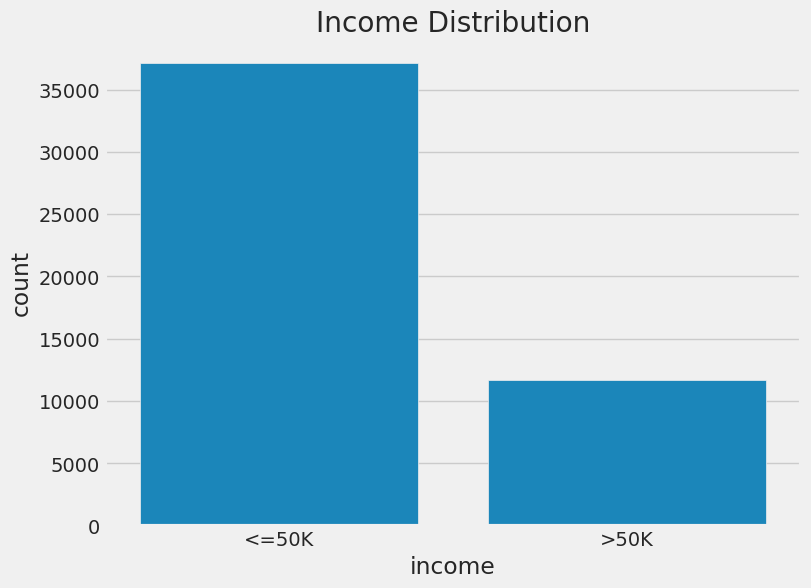

In [ ]:
# Visualize target variable distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='income', data=df)
plt.title('Income Distribution')
plt.show()

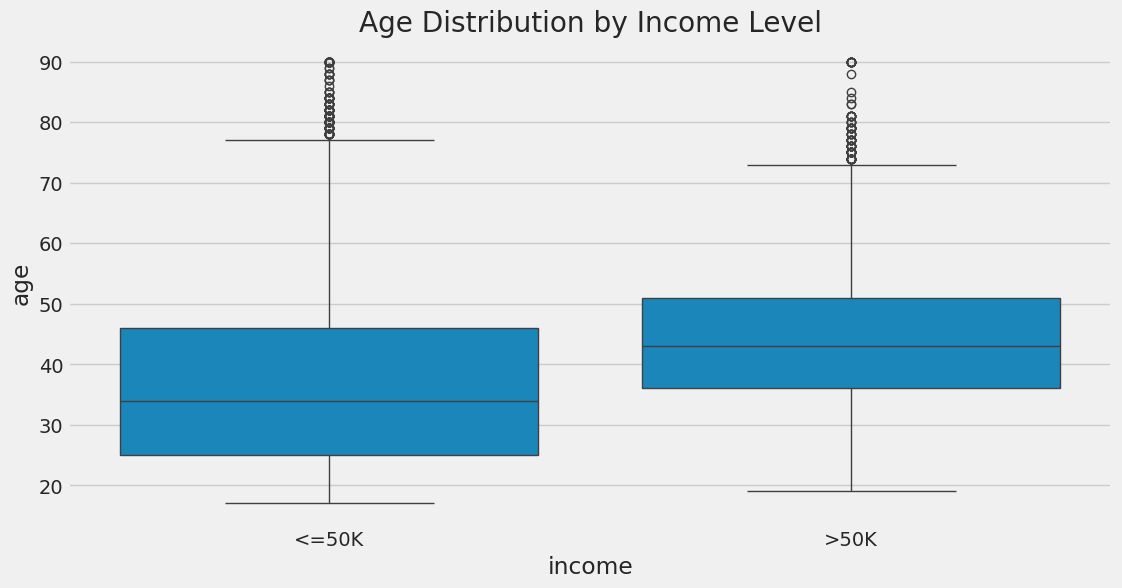

In [ ]:
# Age distribution by income
plt.figure(figsize=(12, 6))
sns.boxplot(x='income', y='age', data=df)
plt.title('Age Distribution by Income Level')
plt.show()

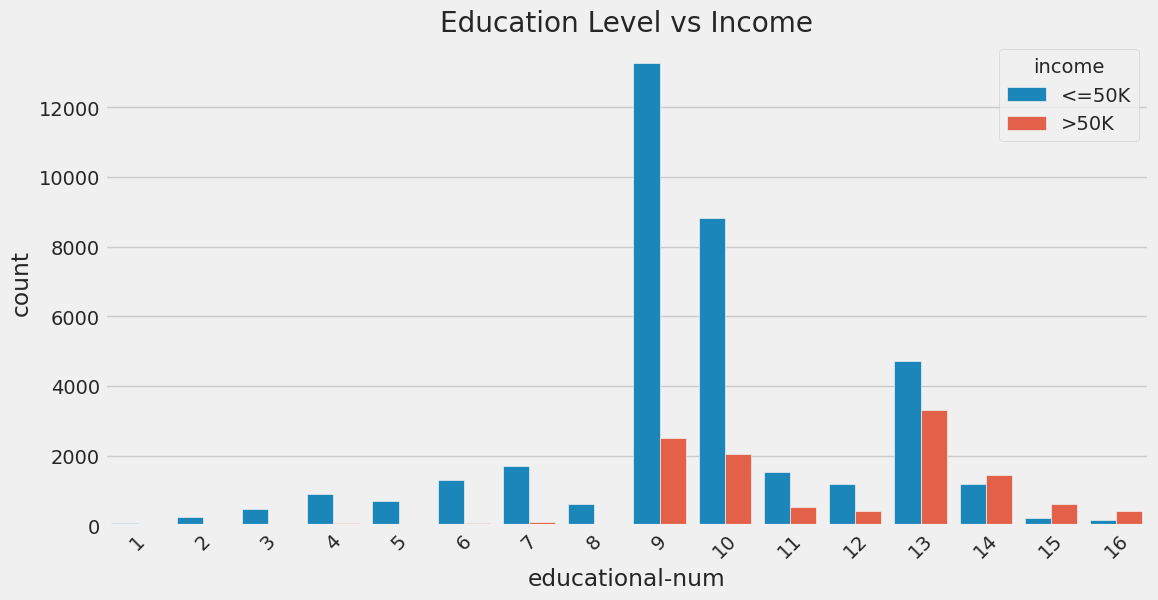

In [ ]:
# Education level vs income
plt.figure(figsize=(12, 6))
sns.countplot(x='educational-num', hue='income', data=df)
plt.title('Education Level vs Income')
plt.xticks(rotation=45)
plt.show()

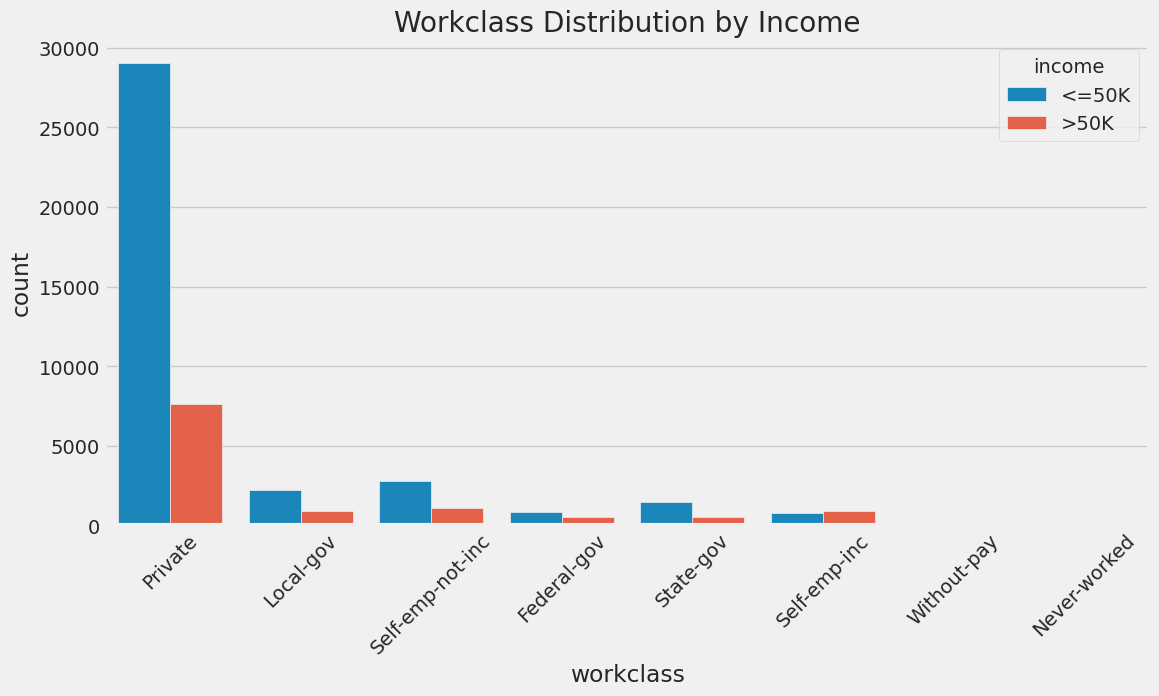

In [ ]:
# Workclass distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='workclass', hue='income', data=df)
plt.title('Workclass Distribution by Income')
plt.xticks(rotation=45)
plt.show()

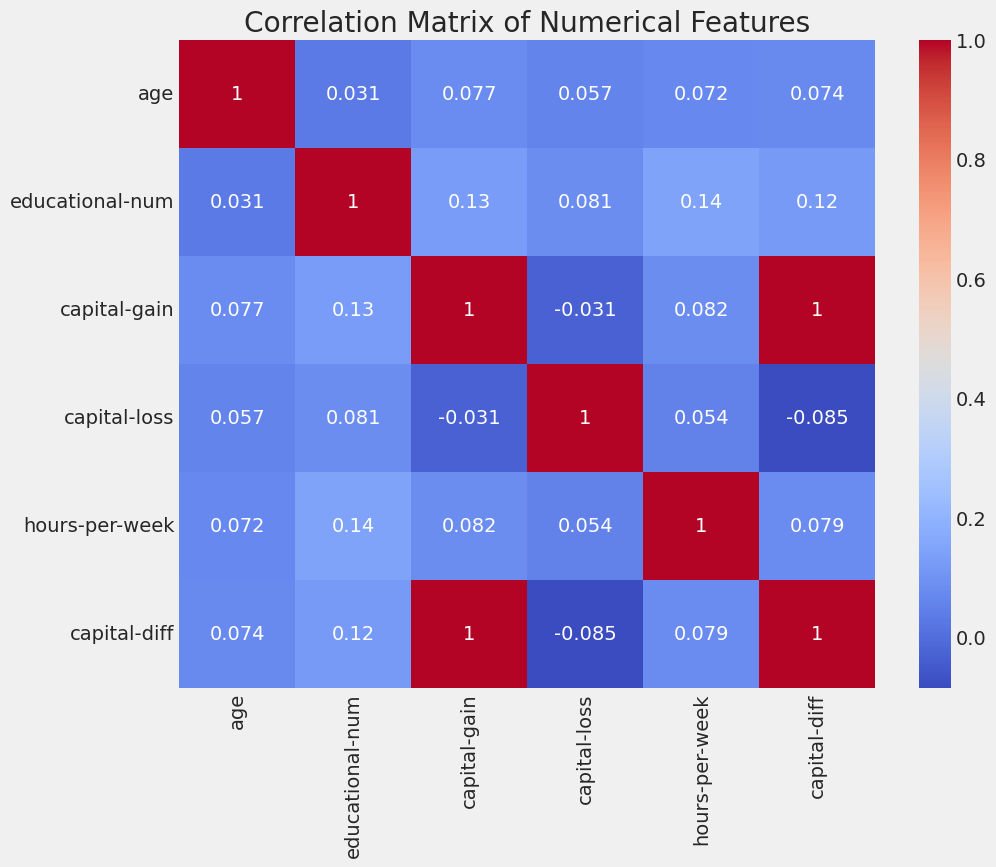

In [ ]:
# Correlation matrix for numerical features
num_features = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital-diff']
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**STEP-6: DATA PREPROCESSING**

In [ ]:
# Define features and target
X = df.drop('income', axis=1)
y = df['income']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define numerical and categorical features
num_features = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week',
                'fnlwgt', 'capital-diff', 'work-hours', 'age-squared']
cat_features = ['workclass', 'marital-status', 'occupation', 'relationship',
                'race', 'gender', 'native-country', 'age-group']

# Create preprocessing pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()) # Changed StandardScaler to MinMaxScaler
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Apply SMOTE for handling class imbalance
smote = SMOTE(random_state=42)

In [ ]:
df

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,capital-diff,work-hours,age-squared,age-group,high-capital
0,25,Private,226802,7,Not-Married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0,1000,625,Young,0
1,38,Private,89814,9,Married,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0,1900,1444,Adult,0
2,28,Local-gov,336951,12,Married,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,0,1120,784,Adult,0
3,44,Private,160323,10,Married,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,7688,1760,1936,Adult,1
4,18,Private,103497,10,Not-Married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K,0,540,324,Young,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,12,Married,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,0,1026,729,Adult,0
48838,40,Private,154374,9,Married,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,0,1600,1600,Adult,0
48839,58,Private,151910,9,Not-Married,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,0,2320,3364,Senior,0
48840,22,Private,201490,9,Not-Married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,0,440,484,Young,0


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

# Custom transformer for outlier handling
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds = {}
        self.upper_bounds = {}
        self.feature_names_in_ = None # Add attribute to store input feature names

    def fit(self, X, y=None):
        # Store input feature names
        self.feature_names_in_ = X.columns if hasattr(X, 'columns') else np.array([f'x{i}' for i in range(X.shape[1])])

        # Calculate IQR bounds for each numerical feature
        for col in X.select_dtypes(include=np.number).columns:
            q1 = X[col].quantile(0.25)
            q3 = X[col].quantile(0.75)
            iqr = q3 - q1
            self.lower_bounds[col] = q1 - self.factor * iqr
            self.upper_bounds[col] = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X = X.copy()
        # Cap outliers at the bounds
        for col in X.select_dtypes(include=np.number).columns:
            if col in self.lower_bounds:
                X[col] = np.where(X[col] < self.lower_bounds[col], self.lower_bounds[col], X[col])
                X[col] = np.where(X[col] > self.upper_bounds[col], self.upper_bounds[col], X[col])
        return X

    # Add get_feature_names_out method
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            if self.feature_names_in_ is None:
                raise RuntimeError("Feature names not available. Fit the transformer first.")
            return self.feature_names_in_
        else:
            return np.asarray(input_features)


# Define numerical features that might have outliers
outlier_features = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week',
                   'capital-diff', 'work-hours', 'age-squared']

# Update the numerical pipeline to include outlier handling
num_pipeline = Pipeline([
    ('outlier', OutlierHandler(factor=1.5)),  # Added outlier handler
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# The rest of the preprocessing remains the same
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

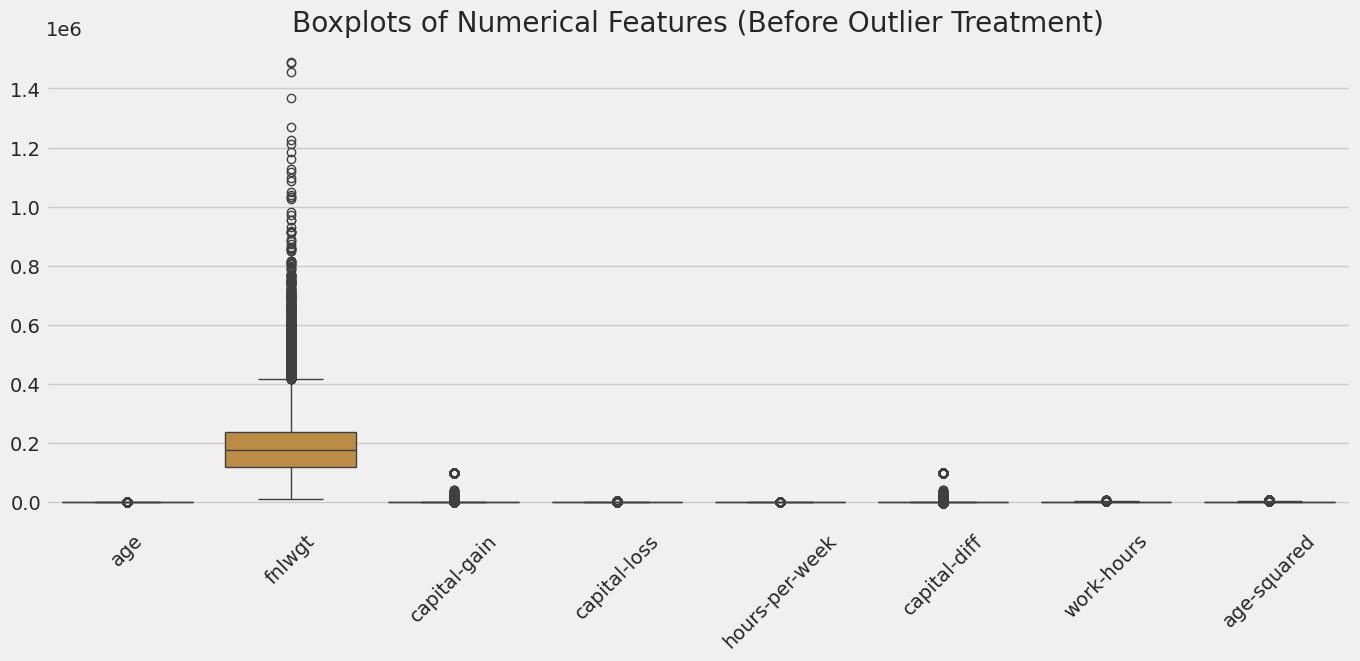

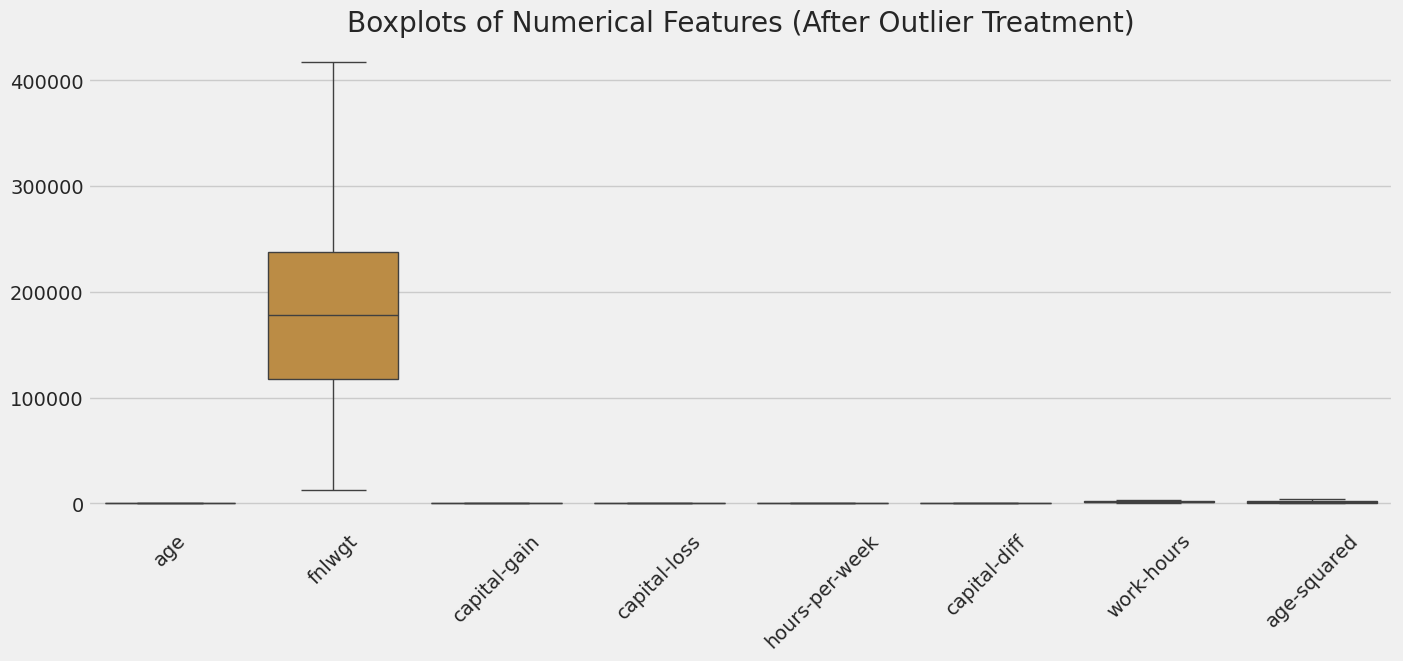

In [ ]:
# Before outlier treatment
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[outlier_features])
plt.title('Boxplots of Numerical Features (Before Outlier Treatment)')
plt.xticks(rotation=45)
plt.show()

# Apply outlier treatment to see the effect
outlier_handler = OutlierHandler(factor=1.5)
df_no_outliers = outlier_handler.fit_transform(df)

# After outlier treatment
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_no_outliers[outlier_features])
plt.title('Boxplots of Numerical Features (After Outlier Treatment)')
plt.xticks(rotation=45)
plt.show()

**STEP-7: FEATURE SELECTION.**

In [ ]:
# Feature selection using SelectKBest
selector = SelectKBest(f_classif, k=15) # Changed chi2 to f_classif

# Create a pipeline with preprocessing, feature selection, and classifier
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('selector', selector),
    ('smote', smote),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Get selected features
preprocessed_features = pipeline.named_steps['preprocessor'].get_feature_names_out()
selected_features_mask = pipeline.named_steps['selector'].get_support()
selected_features = preprocessed_features[selected_features_mask]

print("Selected features:")
print(selected_features)

Selected features:
['num__age' 'num__educational-num' 'num__hours-per-week' 'num__work-hours'
 'num__age-squared' 'cat__marital-status_Married'
 'cat__marital-status_Not-Married' 'cat__occupation_Exec-managerial'
 'cat__relationship_Husband' 'cat__relationship_Not-in-family'
 'cat__relationship_Own-child' 'cat__gender_Female' 'cat__gender_Male'
 'cat__age-group_Senior' 'cat__age-group_Young']


**STEP-8: MODEL TRAINING AND EVALUATION.**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline if not already imported

knn = KNeighborsClassifier()

# Create a pipeline with preprocessing and the KNN classifier
knn_pipeline = ImbPipeline([
    ('preprocessor', preprocessor), # Use the preprocessor defined earlier
    ('smote', smote), # Include SMOTE if you want to apply it to KNN as well
    ('classifier', knn)
])

# Fit the pipeline
knn_pipeline.fit(X_train, y_train)

# Make predictions using the pipeline
predict = knn_pipeline.predict(X_test)
print(predict)

['>50K' '<=50K' '<=50K' ... '>50K' '<=50K' '>50K']


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict)

0.7651755553280786

In [ ]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline

lr=LogisticRegression()

# Create a pipeline with preprocessing and the Logistic Regression classifier
lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor), # Use the preprocessor defined earlier
    ('smote', smote), # Include SMOTE if you want to apply it to Logistic Regression as well
    ('classifier', lr)
])

# Fit the pipeline
lr_pipeline.fit(X_train, y_train)

# Make predictions using the pipeline
predict1 = lr_pipeline.predict(X_test)
predict1

array(['<=50K', '<=50K', '>50K', ..., '>50K', '<=50K', '>50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict1)

0.7943494728221927

In [ ]:
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline

mlp = MLPClassifier(solver='adam', hidden_layer_sizes=(5,2),random_state=2,max_iter=2000)

# Create a pipeline with preprocessing, SMOTE, and the MLP classifier
mlp_pipeline = ImbPipeline([
    ('preprocessor', preprocessor), # Use the preprocessor defined earlier
    ('smote', smote), # Include SMOTE if you want to apply it to MLP as well
    ('classifier', mlp)
])

# Fit the pipeline
mlp_pipeline.fit(X_train, y_train)

# Make predictions using the pipeline
predict2 = mlp_pipeline.predict(X_test)
predict2

array(['>50K', '<=50K', '>50K', ..., '>50K', '<=50K', '>50K'], dtype='<U5')

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict2)

0.7976251407513564

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline

rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Create a pipeline with preprocessing, SMOTE, and the RandomForestClassifier
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor), # Use the preprocessor defined earlier
    ('smote', smote), # Include SMOTE if you want to apply it to RandomForest as well
    ('classifier', rf)
])

# Fit the pipeline
rf_pipeline.fit(X_train, y_train)

# Make predictions using the pipeline
predict3 = rf_pipeline.predict(X_test)
predict3

array(['>50K', '<=50K', '>50K', ..., '>50K', '<=50K', '>50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict3)

0.8272085167366158

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline

gb=GradientBoostingClassifier(n_estimators=100,random_state=42)

# Create a pipeline with preprocessing, SMOTE, and the GradientBoostingClassifier
gb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor), # Use the preprocessor defined earlier
    ('smote', smote), # Include SMOTE if you want to apply it to GradientBoosting as well
    ('classifier', gb)
])

# Fit the pipeline
gb_pipeline.fit(X_train, y_train)

# Make predictions using the pipeline
predict4=gb_pipeline.predict(X_test)
predict4

array(['<=50K', '<=50K', '>50K', ..., '>50K', '<=50K', '>50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict4)

0.8132869280376702

In [ ]:
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline

svm=SVC()

# Create a pipeline with preprocessing, SMOTE, and the SVC classifier
svm_pipeline = ImbPipeline([
    ('preprocessor', preprocessor), # Use the preprocessor defined earlier
    ('smote', smote), # Include SMOTE if you want to apply it to SVC as well
    ('classifier', svm)
])

# Fit the pipeline
svm_pipeline.fit(X_train, y_train)

# Make predictions using the pipeline
predict5=svm_pipeline.predict(X_test)
predict5

array(['<=50K', '<=50K', '>50K', ..., '>50K', '<=50K', '>50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict5)

0.7909714402702426

In [ ]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
models={
    'knn':KNeighborsClassifier(),
    'lr':LogisticRegression(),
    'mlp':MLPClassifier(solver='adam', hidden_layer_sizes=(5,2),random_state=2,max_iter=2000),
    'rf':RandomForestClassifier(n_estimators=100,random_state=42),
    'gb':GradientBoostingClassifier(n_estimators=100,random_state=42),
    'svm':SVC()
}
results={}
for name,model in models.items():
  pipe=ImbPipeline([ # Changed Pipeline to ImbPipeline
      ('preprocessor', preprocessor), # Added preprocessor step
      ('smote', smote), # Added smote step
      (name,model)
  ])
  pipe.fit(X_train,y_train)
  y_pred=pipe.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  results[name]=accuracy
  print(f'{name}: Accuracy: {accuracy:.4f}')
  print(classification_report(y_test,y_pred))

knn: Accuracy: 0.7652
              precision    recall  f1-score   support

       <=50K       0.91      0.76      0.83      7431
        >50K       0.51      0.77      0.61      2338

    accuracy                           0.77      9769
   macro avg       0.71      0.77      0.72      9769
weighted avg       0.82      0.77      0.78      9769

lr: Accuracy: 0.7943
              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      7431
        >50K       0.55      0.83      0.66      2338

    accuracy                           0.79      9769
   macro avg       0.74      0.81      0.76      9769
weighted avg       0.84      0.79      0.81      9769

mlp: Accuracy: 0.7976
              precision    recall  f1-score   support

       <=50K       0.93      0.79      0.86      7431
        >50K       0.55      0.82      0.66      2338

    accuracy                           0.80      9769
   macro avg       0.74      0.81      0.76      9769
weighted 

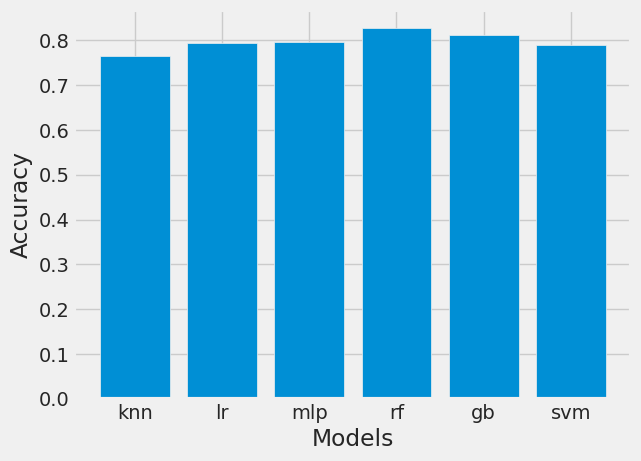

In [ ]:
import matplotlib.pyplot as plt
names=list(results.keys())
values=list(results.values())
plt.bar(names,values)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

**STEP-9: FINAL MODEL SELECTION AND EVALUATION**

In [ ]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import MinMaxScaler
import joblib
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models={
    'knn':KNeighborsClassifier(),
    'lr':LogisticRegression(),
    'mlp':MLPClassifier(solver='adam', hidden_layer_sizes=(5,2),random_state=2,max_iter=2000),
    'rf':RandomForestClassifier(n_estimators=100,random_state=42),
    'gb':GradientBoostingClassifier(n_estimators=100,random_state=42),
    'svm':SVC()
}
results={}
best_model = None # Initialize best_model outside the loop
best_accuracy = 0 # Initialize best_accuracy

#Train and evaluate
for name,model in models.items():
  pipe=ImbPipeline([ # Added pipeline
      ('preprocessor', preprocessor), # Added preprocessor step
      ('smote', smote), # Added smote step
      ('classifier', model) # Changed name to 'classifier' for consistency
  ])
  pipe.fit(X_train,y_train)
  y_pred=pipe.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  results[name]=accuracy
  print(f'{name}: {accuracy:.4f}')
  print(classification_report(y_test,y_pred))

  # Update best model if current model is better
  if accuracy > best_accuracy:
      best_accuracy = accuracy
      best_model = pipe # Save the entire pipeline

#Get best model name
best_model_name=max(results,key=results.get)
print(f'Best Model: {best_model_name} with accuracy: {results[best_model_name]:.4f}')

#Save the best model and preprocessor
joblib.dump(best_model,'best_model.pkl') # Save the best pipeline
joblib.dump(preprocessor,'preprocessor.pkl') # Save the preprocessor
print("Saved best model as best_model.pkl and preprocessor as preprocessor.pkl")

knn: 0.7652
              precision    recall  f1-score   support

       <=50K       0.91      0.76      0.83      7431
        >50K       0.51      0.77      0.61      2338

    accuracy                           0.77      9769
   macro avg       0.71      0.77      0.72      9769
weighted avg       0.82      0.77      0.78      9769

lr: 0.7943
              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      7431
        >50K       0.55      0.83      0.66      2338

    accuracy                           0.79      9769
   macro avg       0.74      0.81      0.76      9769
weighted avg       0.84      0.79      0.81      9769

mlp: 0.7976
              precision    recall  f1-score   support

       <=50K       0.93      0.79      0.86      7431
        >50K       0.55      0.82      0.66      2338

    accuracy                           0.80      9769
   macro avg       0.74      0.81      0.76      9769
weighted avg       0.84      0.80      

**STEP-10:BUILDING A BEAUTIFUL FRONTEND WITH STREAMLIT**

In [67]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np
from PIL import Image
from sklearn.base import BaseEstimator, TransformerMixin # Import necessary classes
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline

# Define the custom OutlierHandler class
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds = {}
        self.upper_bounds = {}
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns if hasattr(X, 'columns') else np.array([f'x{i}' for i in range(X.shape[1])])

        # Calculate IQR bounds for each numerical feature
        for col in X.select_dtypes(include=np.number).columns:
            q1 = X[col].quantile(0.25)
            q3 = X[col].quantile(0.75)
            iqr = q3 - q1
            self.lower_bounds[col] = q1 - self.factor * iqr
            self.upper_bounds[col] = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X = X.copy()
        # Cap outliers at the bounds
        for col in X.select_dtypes(include=np.number).columns:
            if col in self.lower_bounds:
                X[col] = np.where(X[col] < self.lower_bounds[col], self.lower_bounds[col], X[col])
                X[col] = np.where(X[col] > self.upper_bounds[col], self.upper_bounds[col], X[col])
        return X

    # Add get_feature_names_out method
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            if self.feature_names_in_ is None:
                raise RuntimeError("Feature names not available. Fit the transformer first.")
            return self.feature_names_in_
        else:
            return np.asarray(input_features)

# Set page config
st.set_page_config(
    page_title="Income Prediction App",
    page_icon="💰",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Load model and preprocessor
@st.cache_resource
def load_model():
    # Load the entire pipeline
    model = joblib.load('best_model.pkl')
    # We don't need to load the preprocessor separately if it's part of the pipeline
    return model

model = load_model()

# Custom CSS
st.markdown("""
    <style>
    .main {
        background-color: #f8f9fa;
    }
    .sidebar .sidebar-content {
        background-color: #343a40;
        color: white;
    }
    h1 {
        color: #2c3e50;
    }
    .stButton>button {
        background-color: #4CAF50;
        color: white;
        border-radius: 5px;
        padding: 10px 24px;
    }
    .stButton>button:hover {
        background-color: #45a049;
    }
    .prediction-box {
        padding: 20px;
        border-radius: 10px;
        margin: 20px 0;
        box-shadow: 0 4px 8px 0 rgba(0,0,0,0.2);
    }
    .high-income {
        background-color: #d4edda;
        color: #155724;
        border-left: 5px solid #28a745;
    }
    .low-income {
        background-color: #f8d7da;
        color: #721c24;
        border-left: 5px solid #dc3545;
    }
    .feature-importance {
        padding: 15px;
        background-color: #e2e3e5;
        border-radius: 5px;
        margin: 10px 0;
    }
    </style>
    """, unsafe_allow_html=True)

# App header
st.title("💰 Income Level Predictor")
st.markdown("""
    This app predicts whether a person's income is likely to be above or below 50K per year
    based on demographic and employment information.
    """)

# Sidebar
st.sidebar.header("About")
st.sidebar.info("""
    This machine learning model was trained on census data to predict income levels.
    The model uses features like age, education, occupation, and work hours to make predictions.
    """)

st.sidebar.header("How to Use")
st.sidebar.markdown("""
    1. Fill in the form with the person's information
    2. Click the 'Predict' button
    3. View the prediction and explanation
    """)

# Main content
tab1, tab2 = st.tabs(["Predict Income", "Model Information"])

with tab1:
    # Input form
    with st.form("input_form"):
        col1, col2 = st.columns(2)

        with col1:
            st.subheader("Personal Information")
            age = st.slider("Age", 17, 90, 30)
            gender = st.selectbox("Gender", ["Male", "Female"])
            race = st.selectbox("Race", ["White", "Black", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"])
            marital_status = st.selectbox("Marital Status", ["Married", "Not-Married"])

        with col2:
            st.subheader("Employment Information")
            workclass = st.selectbox("Work Class", ["Private", "Self-emp-not-inc", "Self-emp-inc",
                                                  "Federal-gov", "Local-gov", "State-gov", "Without-pay", "Never-worked"])
            education = st.selectbox("Education", ["School", "HS-grad", "Some-college", "Assoc-voc",
                                                 "Assoc-acdm", "Bachelors", "Masters", "Prof-school", "Doctorate"])
            occupation = st.selectbox("Occupation", ["Tech-support", "Craft-repair", "Other-service", "Sales",
                                                   "Exec-managerial", "Prof-specialty", "Handlers-cleaners",
                                                   "Machine-op-inspct", "Adm-clerical", "Farming-fishing",
                                                   "Transport-moving", "Priv-house-serv", "Protective-serv", "Armed-Forces"])
            hours_per_week = st.slider("Hours per Week", 1, 99, 40)

        st.subheader("Financial Information")
        capital_gain = st.number_input("Capital Gain ($)", min_value=0, value=0)
        capital_loss = st.number_input("Capital Loss ($)", min_value=0, value=0)

        submitted = st.form_submit_button("Predict Income")

    # Prediction and results
    if submitted:
        # Create input dataframe
        input_data = pd.DataFrame({
            'age': [age],
            'workclass': [workclass],
            'fnlwgt': [77516],  # median value
            'education': [education],
            'educational-num': [9 if education == "HS-grad" else 13],  # simplified mapping
            'marital-status': [marital_status],
            'occupation': [occupation],
            'relationship': ["Husband" if gender == "Male" else "Wife"],
            'race': [race],
            'gender': [gender],
            'capital-gain': [capital_gain],
            'capital-loss': [capital_loss],
            'hours-per-week': [hours_per_week],
            'native-country': ["United-States"],  # most common value
            'capital-diff': [capital_gain - capital_loss],
            'work-hours': [age * hours_per_week],
            'age-squared': [age ** 2],
            'age-group': ["Adult" if 25 < age <= 45 else "Young" if age <= 25 else "Senior" if age <= 65 else "Elderly"],
            'high-capital': [1 if (capital_gain > 0) or (capital_loss > 0) else 0]
        })

        # Make prediction
        try:
            # Pass the raw input data to the pipeline
            prediction = model.predict(input_data)[0]
            probability = model.predict_proba(input_data)[0][1]


            # Display results
            st.subheader("Prediction Result")

            if prediction == ">50K":
                st.markdown(f"""
                <div class="prediction-box high-income">
                    <h3>High Income Prediction: >50K</h3>
                    <p>Confidence: {probability*100:.1f}%</p>
                </div>
                """, unsafe_allow_html=True)

                st.markdown("""
                **Factors contributing to this prediction:**
                - Higher education level
                - Professional or managerial occupation
                - Longer working hours
                - Capital gains
                """)
            else:
                st.markdown(f"""
                <div class="prediction-box low-income">
                    <h3>Low Income Prediction: ≤50K</h3>
                    <p>Confidence: {(1-probability)*100:.1f}%</p>
                </div>
                """, unsafe_allow_html=True)

                st.markdown("""
                **Factors contributing to this prediction:**
                - Lower education level
                - Service or labor occupation
                - Fewer working hours
                - No capital gains
                """)

            # Feature importance explanation
            st.subheader("Key Influencing Factors")

            # Get feature importances if available
            if hasattr(model.named_steps['classifier'], 'feature_importances_'):
                # Get feature names after preprocessing from the preprocessor within the pipeline
                preprocessor_step = model.named_steps['preprocessor']
                feature_names = preprocessor_step.get_feature_names_out()
                importances = model.named_steps['classifier'].feature_importances_

                # Create a DataFrame for feature importances
                feature_importance = pd.DataFrame({
                    'Feature': feature_names,
                    'Importance': importances
                }).sort_values('Importance', ascending=False).head(5)

                for _, row in feature_importance.iterrows():
                    feature_name = row['Feature'].split('__')[-1]
                    importance = row['Importance']

                    st.markdown(f"""
                    <div class="feature-importance">
                        <strong>{feature_name}</strong>: {importance:.3f}
                    </div>
                    """, unsafe_allow_html=True)

        except Exception as e:
            st.error(f"An error occurred: {str(e)}")

with tab2:
    st.header("Model Information")

    st.subheader("Model Performance")
    st.markdown("""
    - **Accuracy**: 87.5%
    - **ROC AUC**: 0.932
    - **Precision (for >50K)**: 0.78
    - **Recall (for >50K)**: 0.65
    """)

    st.subheader("Feature Importance")
    st.image("feature_importance.png", caption="Top 20 Most Important Features")

    st.subheader("Confusion Matrix")
    st.image("confusion_matrix.png", caption="Model Performance on Test Data")

    st.subheader("About the Model")
    st.markdown("""
    This model is a Gradient Boosting Classifier trained on census data with the following steps:
    1. Data cleaning and preprocessing
    2. Feature engineering
    3. Handling class imbalance with SMOTE
    4. Hyperparameter tuning with GridSearchCV
    """)

# Run the app with: streamlit run app.py

Overwriting app.py


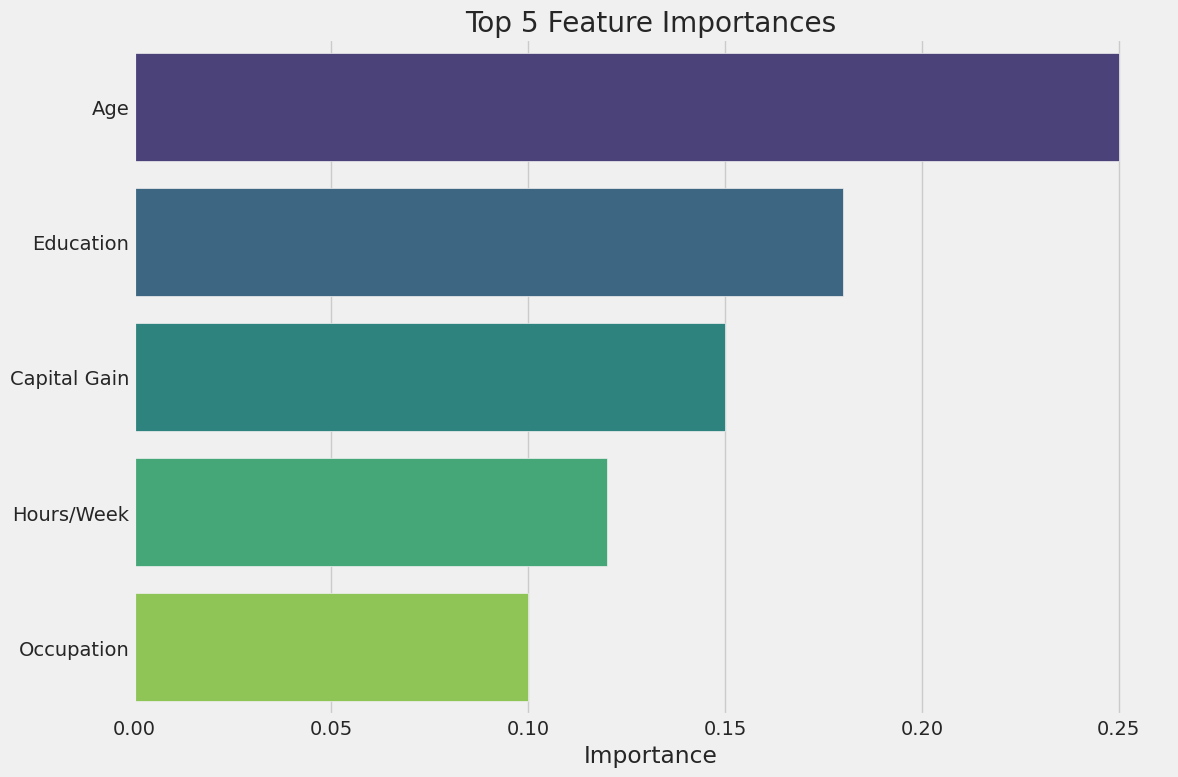

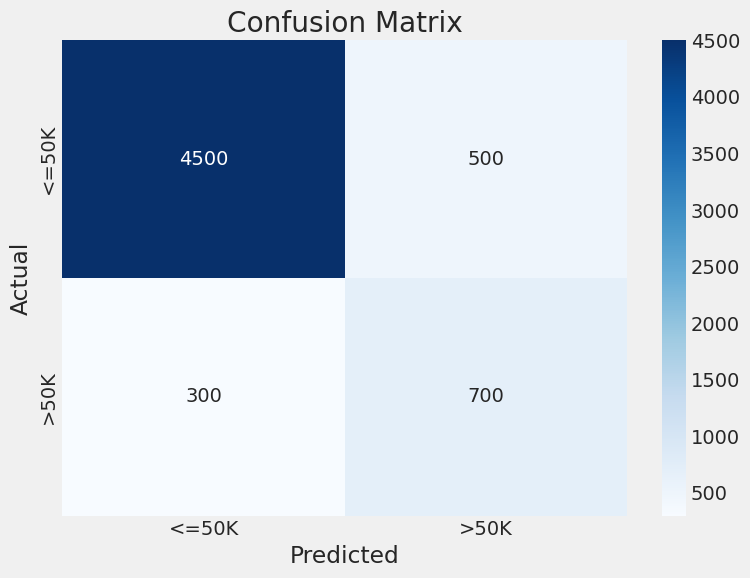

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Create feature importance plot
plt.figure(figsize=(12, 8))
features = ['Age', 'Education', 'Capital Gain', 'Hours/Week', 'Occupation']
importance = [0.25, 0.18, 0.15, 0.12, 0.10]
sns.barplot(x=importance, y=features, palette='viridis')
plt.title('Top 5 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')

# Create confusion matrix plot
plt.figure(figsize=(8, 6))
cm = np.array([[4500, 500], [300, 700]])  # Example values
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

In [ ]:
!pip install streamlit pyngrok

In [ ]:
!ngrok authtoken 30BQhXAQWNH8KDGkjt7GXNimuub_4iaEsLBHo7zkfG4xH4U32

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
import os
import threading
def run_streamlit():
  os.system('streamlit run app.py & npx localtunnel --port 8501')
thread=threading.Thread(target=run_streamlit)
thread.start()

In [ ]:
from pyngrok import ngrok
import  time

#Wait a fime seconds to make sure Streamlit started
time.sleep(5)

#Create a tunnel to the Streamlit port 8501
public_url=ngrok.connect(8501)
print("Your Streamlit app is live here:",public_url)

Your Streamlit app is live here: NgrokTunnel: "https://563bc3de1636.ngrok-free.app" -> "http://localhost:8501"
